In [1]:
import sys
import importlib

def install_if_missing(package, import_name=None):
    """Install a package only if it's not already installed"""
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package}...")
        !{sys.executable} -m pip install {package} -q
        print(f"{package} installed ✅")
    else:
        print(f"{package} already available ✅")

install_if_missing("datasets")
install_if_missing("tqdm")
install_if_missing("ipywidgets")

datasets already available ✅
tqdm already available ✅
ipywidgets already available ✅


In [2]:
# Imports
import os

import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam

from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.3.1
Device          : cpu


In [3]:
# Load dataset
dataset = load_dataset("jiovine/pixel-art-nouns")['train']

In [4]:
# Extract all the text from the dataset
texts = [sample['text'] for sample in dataset]

In [5]:
# Definition of the tokenizer
def tokenize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s-]', '', text)
    text = text.replace('-', ' - ')
    return text.split()

In [6]:
def encode(text, max_len=30):
    tokens = tokenize_text(text)
    ids = [word2idx['<BOS>']]
    ids += [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    ids += [word2idx['<EOS>']]
    # Pad or truncate
    ids = ids[:max_len]
    ids += [word2idx['<PAD>']] * (max_len - len(ids))
    return ids

def decode(ids):
    words = [idx2word[i] for i in ids 
             if i not in [word2idx['<PAD>'], word2idx['<BOS>'], word2idx['<EOS>']]]
    return ' '.join(words)

In [7]:
# Build the vocab
word_counts = Counter()
for text in texts:
    word_counts.update(tokenize_text(text))

special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

vocab = special_tokens + [word for word, count in word_counts.most_common()]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=4, ff_mult=4):
        super().__init__()

        # Self Attention
        self.norm1   = nn.LayerNorm(dim)
        self.attn    = nn.MultiheadAttention(dim, n_heads, batch_first=True)

        # MLP/Feed Forward
        self.norm2   = nn.LayerNorm(dim)
        self.ff      = nn.Sequential(
            nn.Linear(dim, dim * ff_mult),
            nn.GELU(),
            nn.Linear(dim * ff_mult, dim)
        )

    def forward(self, x, padding_mask=None):
        # Attention
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=padding_mask)
        # Residual
        x  = x + attn_out

        # Feed Forward + Residual
        x = x + self.ff(self.norm2(x))
        return x

In [9]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, dim=128, n_layers=4, n_heads=4, max_len=28):
        """
        vocab_size : size of your tokenizer vocabulary
        dim        : embedding dimension
        n_layers   : number of transformer blocks
        n_heads    : number of attention heads
        max_len    : maximum sequence length
        """
        super().__init__()

        self.dim     = dim

        # Embedding (Pos + Token)
        # Each token is projected into a space of dimension dim
        self.token_emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        # Reguarding the position of the token he is also projected into a space of dimension dim
        self.pos_emb  = nn.Embedding(max_len, dim)

        # Transformersblocks
        self.blocks = nn.ModuleList([
            TransformerBlock(dim, n_heads) for _ in range(n_layers)
        ])

        # Norm
        self.norm = nn.LayerNorm(dim)

    def forward(self, tokens, padding_mask=None):
        """
        tokens       : (B, seq_len) token ids
        padding_mask : (B, seq_len) True where padding
        returns      : (B, seq_len, dim) text embeddings
        """
        B, seq_len = tokens.shape

        # Embedding
        # To get the positions of each tokens
        positions = torch.arange(seq_len, device=tokens.device).unsqueeze(0)  # (1, seq_len)

        # Compute the embedding
        x = self.token_emb(tokens) + self.pos_emb(positions) # (B, seq_len, dim)

        # Transformers block
        for block in self.blocks:
            x = block(x, padding_mask) # to not influence attetion 

        return self.norm(x)   # (B, seq_len, dim)

In [10]:
# Let's create the function that add noise
def add_noise(x0,t):
    # Compute the noise
    noise = torch.randn_like(x0)
    # Get the wanted alpha bar
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    # Compute xt
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    return x_t, noise

In [11]:
class CrossAttention(nn.Module):
    def __init__(self, query_dim, context_dim, n_heads=4):
        """
        query_dim   : dimension of image features (from U-Net)
        context_dim : dimension of text embeddings (from Text Encoder)
        n_heads     : number of attention heads
        """
        super().__init__()
        assert query_dim % n_heads == 0, "query_dim must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = query_dim // n_heads
        self.scale = self.head_dim  -0.5

        # Normalization
        self.norm_image = nn.LayerNorm(query_dim)
        self.norm_text = nn.LayerNorm(context_dim)

        # Q from image, K and V from text
        self.q_proj = nn.Linear(query_dim, query_dim)
        self.k_proj = nn.Linear(context_dim, query_dim)
        self.v_proj = nn.Linear(context_dim, query_dim)

        # Output
        self.out_proj = nn.Linear(query_dim, query_dim)

    def forward(self, x, context):
        """
        x       : (B, H*W, query_dim)   image features
        context : (B, seq_len, context_dim) text embeddings
        returns : (B, H*W, query_dim)
        """

        # Get the shape
        B, HW, _ = x.shape
        _, seq_len, _ = context.shape

        # Normalize
        x_norm = self.norm_image(x)
        ctx_norm = self.norm_text(context)

        # Compute Q, K, V 
        q = self.q_proj(x_norm) # (B, H*W, query_dim)

        # projection of context_dim to query_dim
        k = self.k_proj(ctx_norm) # (B, seq_len, query_dim)
        v = self.v_proj(ctx_norm) # (B, seq_len, query_dim)

        # Reshape
        q = q.view(B, HW,self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, HW, head_dim)
        k = k.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)
        v = v.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)

        # Scaled dot-product attention
        out = F.scaled_dot_product_attention(q, k, v) # (B, n_heads, HW, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, HW, -1) # (B, HW, query_dim)

        # Output + residual
        return self.out_proj(out) + x # (B, H*W, query_dim)

In [12]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # At this point we could implement on top of the sinusoide embedding a small MLP to project better

    def sinusoidal_embedding(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

    def forward(self,t):
        return self.sinusoidal_embedding(t)

In [13]:
class ResBlock(nn.Module):
    def __init__(self, in_channels:int,out_channels:int,emb_dim:int):
        """
        in_channels : number of input channels
        out_channels : number of output channels
        emb_dim : dimension of the timestep embedding
        """

        super().__init__()

        # First block
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels), #split channels into group of 8
            nn.SiLU(),
            nn.Conv2d(in_channels,out_channels, kernel_size=3,padding=1)
        )

        # Embedding projection
        # We need to project the embedding in order to be in the same space while adding
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels)
        )

        # Second block
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels,out_channels, kernel_size=3,padding=1)
        )

        # Skip connection
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) #too match if different
        else:
            self.skip = nn.Identity()

    def forward(self,x,t_emb):
        """
        x     : (B, in_channels, H, W)
        t_emb : (B, emb_dim)
        """

        # First block
        # (B, out_channels, H, W)
        h = self.block1(x)

        # Add time step embedding
        # (B, emb_dim)
        t = self.time_proj(t_emb)
        # (B, out_channels)

        # Add by broadcasting
        h = h + t[:, :, None, None]

        # Second block
        # (B, out_channels, H, W)
        h = self.block2(h)

        # Skip connection
        return h + self.skip(x)

In [14]:
class SelfAttention(nn.Module):
    def __init__(self, channels:int,n_heads:int=4):
        """
        channels : number of input/output channels
        n_heads  : number of attention heads
        """
        super().__init__()
        assert channels % n_heads == 0

        self.channels = channels
        self.n_heads = n_heads
        self.head_dim = channels // n_heads

        # Normalization
        self.norm = nn.GroupNorm(8, channels)

        # Q,K,V Linear
        self.qkv = nn.Linear(channels, channels * 3)
        self.output = nn.Linear(channels,channels)

    def forward(self,x):
        """
        x : (B, C, H, W)
        """

        B,C,H,W = x.shape

        # Norm
        h = self.norm(x)

        # Flatten
        h = h.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)

        # Compute Q, K, V
        qkv = self.qkv(h) # (B, H*W, 3*C)
        q,k,v = qkv.chunk(3, dim=-1) # 3*(B, H*W, C)

        # At this point, the differents head are inside q,k,v s we need to split thoses matrix depending on n_heads
        def split_heads(t):
                    return t.view(B, H * W, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, H*W, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Dot-product attention
        scale  = self.head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale  # (B, n_heads, H*W, H*W)
        attn   = torch.softmax(scores, dim=-1) # (B, n_heads, H*W, H*W)

        # Weighted sum of values
        out = torch.matmul(attn, v) # (B, n_heads, H*W, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous()  # (B, H*W, n_heads, head_dim)
        out = out.view(B, H * W, C) # (B, H*W, C)

        # Output projection
        out = self.output(out) # (B, H*W, C)

        # Reshape
        out = out.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Return with residual
        return out + x    
        

In [15]:
class UNet(nn.Module):
    def __init__(
        self, 
        in_channels:int=3,
        base_channels:int=32,
        channel_mults = (1,2,4),
        n_heads = 4,
        emb_dim =128,
        context_dim=128,
    ):
        super().__init__()

        self.emb_dim = emb_dim
        channels = [base_channels * i for i in channel_mults]

        # Timestep embedding
        self.time_emb = TimestepEmbedding(emb_dim)

        # init conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        ###########
        # Encoder #
        ###########

        # To increase the number of channels and learn multiple features
        self.encoder_blocks = nn.ModuleList()
        # To reduce the size of the input and see the features more precisely/largelly
        self.downsamplers = nn.ModuleList()

        in_ch = base_channels
        for out_ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch,  out_ch, emb_dim), # Changes the channel dimension
                ResBlock(out_ch, out_ch, emb_dim), # Work in the same space -> extracts more complex patterns
            ]))
            self.downsamplers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)
            )
            in_ch = out_ch

        ##############
        # Bottleneck #
        ##############
        mid_ch = channels[-1]
        self.bottleneck = nn.ModuleList([
            ResBlock(mid_ch, mid_ch, emb_dim),
            SelfAttention(mid_ch, n_heads),
            CrossAttention(mid_ch, context_dim), # NEW -> Add the cross attention in the middle of the bottleneck
            ResBlock(mid_ch, mid_ch, emb_dim),
        ])

        ###########
        # Decoder #
        ###########
        # Reduce the number of channels and features
        self.decoder_blocks = nn.ModuleList()
        # Increase the size of the value inside the bottlenck
        self.upsamplers      = nn.ModuleList()

        for out_ch in reversed(channels):
            self.upsamplers.append(
                nn.ConvTranspose2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
            )
            self.decoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch + out_ch, out_ch, emb_dim),   # +out_ch for skip connection
                ResBlock(out_ch, out_ch, emb_dim),
            ]))
            in_ch = out_ch

        # Final conv that predict the noise
        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
        )
        
    def forward(self, x, t, text_emb=None):
        """
        x : (B, 3, 32, 32) noisy image
        t : (B,)            timestep
        text_emb : (B, seq_len, context_dim)
        returns predicted noise ε (B, 3, 32, 32)
        """

        # Timestep embedding
        t_emb = self.time_emb(t) # (B, emb_dim)

        x = self.init_conv(x) 

        ### Encoder ###
        skips = []
        for (res1, res2), down in zip(self.encoder_blocks, self.downsamplers):
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock
            skips.append(x)
            x = down(x) # DownSample

        ### Bottleneck ###
        B, C, H, W = x.shape
        res1, attn, cross, res2 = self.bottleneck

        # Classic
        x = res1(x, t_emb)
        x = attn(x)

        # If text conditionning
        if text_emb is not None:
            x_flat = x.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)
            x_flat = cross(x_flat, text_emb) # (B, H*W, C)
            x = x_flat.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Classic
        x = res2(x, t_emb)

        ### Decoder ###
        for (res1, res2), up, skip in zip(self.decoder_blocks, self.upsamplers, reversed(skips)):
            x = up(x) # UpSample
            x = torch.cat([x, skip], dim=1) # Add the residual
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock

        # Final conv
        return self.final(x)

In [16]:
# Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PRETRAINED = "pixeldiffusion_conditioned_epoch_140.pt" 
CHECKPOINT_DIR = "./"
epochs = 150
lr = 2e-4
textEncoderDim = 128
T = 1000
batch_size = 64
image_size = 32
MAX_LEN = 28+2
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = (1 - betas).to(device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

In [17]:
# Model init
model        = UNet().to(device)
text_encoder = TextEncoder(vocab_size=len(word2idx), dim=textEncoderDim, max_len=MAX_LEN).to(device)

# Load checkpoiny
checkpoint_path = os.path.join(CHECKPOINT_DIR, PRETRAINED)
try:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state'], strict=False)
    text_encoder.load_state_dict(checkpoint['text_encoder_state'], strict=False)

    print(f"Models loaded")
    print(f"Trained for : {checkpoint['epoch']} epochs")
    print(f"Last loss : {checkpoint['loss']:.6f}")

except FileNotFoundError:
    print(f"No checkpoint found at {checkpoint_path}")

Models loaded
Trained for : 140 epochs
Last loss : 0.003274


In [18]:
# Eval mode
model.eval()
text_encoder.eval()

print(f"\nU-Net params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Text Encoder params : {sum(p.numel() for p in text_encoder.parameters()):,}")
print(f"Device : {device}")


U-Net params : 3,569,443
Text Encoder params : 837,632
Device : cpu


In [19]:
# Sampling
@torch.no_grad()
def sample_conditioned(model, text_encoder, prompt, n_samples=4, device=device):

    # Eval mode
    model.eval()
    text_encoder.eval()

    # Tokenized the text
    tokens = torch.tensor([encode(prompt)] * n_samples, dtype=torch.long ).to(device)                                                # (n_samples, MAX_LEN)
    padding_mask = (tokens == word2idx['<PAD>']).to(device)

    # Encode the text
    text_emb = text_encoder(tokens, padding_mask)

    # Pure noise
    x = torch.randn(n_samples, 3, 32, 32, device=device)

    # Reverse diffusion loop 
    for t in tqdm(reversed(range(T)), desc=f'Sampling: "{prompt[:30]}..."', total=T):

        # Current timestep for all samples
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

        # Predict noise conditioned on text
        eps_pred = model(x, t_tensor, text_emb)

        # Compute the different value of alpha, alpha_bar and beta
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        # Compute x_{t-1}
        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        x_prev = (1 / torch.sqrt(alpha_t)) * (x - coeff * eps_pred)

        # Add noise only if t > 0 -> To add diversity
        if t > 0:
            x_prev = x_prev + torch.sqrt(beta_t) * torch.randn_like(x)

        x = x_prev

    return x

In [20]:
def display_conditioned(samples, prompt):
    n   = samples.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))

    if n == 1:
        axes = [axes]

    for ax, img in zip(axes, samples):
        img_display = (img.cpu().permute(1, 2, 0).numpy() + 1) / 2
        img_display = np.clip(img_display, 0, 1)
        ax.imshow(img_display, interpolation='nearest')
        ax.axis('off')

    plt.suptitle(f'"{prompt}"', fontsize=9, wrap=True)
    plt.tight_layout()
    plt.show()

Sampling: "a character with square black ...": 100%|█| 1000/1000 [00:40<00:00, 2


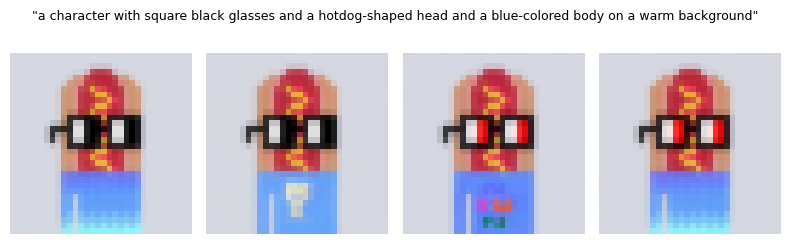

Sampling: "a character with round glasses...": 100%|█| 1000/1000 [00:41<00:00, 2


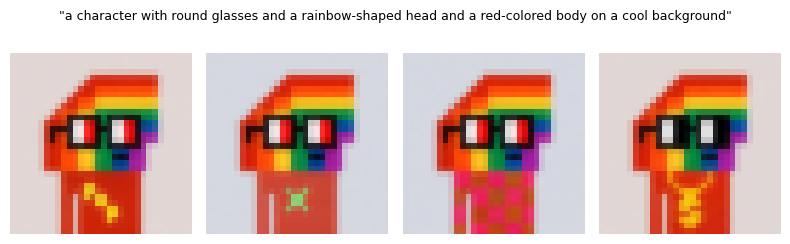

Sampling: "a character with dark green gl...": 100%|█| 1000/1000 [00:42<00:00, 2


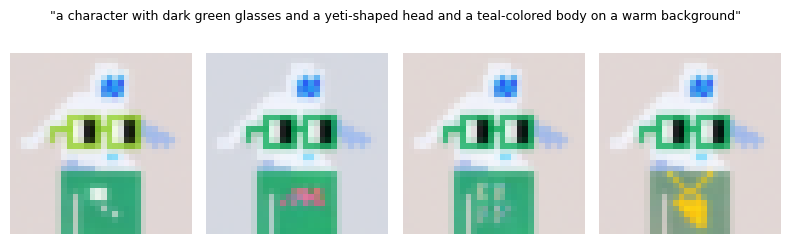

In [21]:
# Test
prompts = [
    "a character with square black glasses and a hotdog-shaped head and a blue-colored body on a warm background",
    "a character with round glasses and a rainbow-shaped head and a red-colored body on a cool background",
    "a character with dark green glasses and a yeti-shaped head and a teal-colored body on a warm background",
]

for prompt in prompts:
    samples = sample_conditioned(
        model        = model,
        text_encoder = text_encoder,
        prompt       = prompt,
        n_samples    = 4,
        device       = device
    )
    display_conditioned(samples, prompt)